In [ ]:
"""
Data Cleaning and Preprocessing Summary

1. Duplicate Row Handling
- Created a copy of the training dataset to preserve the original data.
- Identified and removed duplicate rows to ensure data uniqueness.
- Verified that no duplicate rows remained.

2. Feature Redundancy and Variability Handling
- Checked for duplicate columns (features) and found none.
- Checked for constant features (columns with only one unique value) and found none.
- Applied a variance threshold (0.01) to detect and remove near-zero variance features
  from both the training and test datasets.

3. Outlier Treatment
- Calculated the 5th and 95th percentiles for each feature.
- Clipped feature values to fall within these percentile bounds to reduce the impact of outliers.
- Applied the same clipping process to the test dataset.

4. Saving the Cleaned Data
- Saved the cleaned training and test datasets as 'filtered_train.csv' and 'filtered_test.csv'
  for further modeling.
"""

import pandas as pd
from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import OneHotEncoder

# Load the datasets
train_df = pd.read_csv('../data/train.csv')
test_df = pd.read_csv('../data/test.csv')


print("Starting data cleaning and preprocessing...")

# Step 1: Duplicate Row Handling
print("\n[1] Duplicate Row Handling")
filtered_train_df = train_df.copy()
print("- Made a copy of the training data.")

duplicates = filtered_train_df.duplicated().sum()
print(f"- Number of duplicate rows found: {duplicates}")

filtered_train_df.drop_duplicates(inplace=True)
duplicates_after = filtered_train_df.duplicated().sum()
print(f"- Number of duplicate rows after removal: {duplicates_after}")

# Step 2: Feature Redundancy and Variability Handling
print("\n[2] Feature Redundancy and Variability Handling")

# Check for duplicate columns
print("- Checking for duplicate columns...")
col = filtered_train_df.columns
duplicate_features = []
for i in range(len(col)):
    for j in range(i + 1, len(col)):
        if filtered_train_df[col[i]].equals(filtered_train_df[col[j]]):
            duplicate_features.append((col[i], col[j]))

if duplicate_features:
    print(f"- Duplicate features found: {duplicate_features}")
else:
    print("- No duplicate features found.")

# Check for constant features
print("- Checking for constant features...")
constant_features = [col for col in filtered_train_df.columns if filtered_train_df[col].nunique() == 1]

if constant_features:
    print(f"- Constant features found: {constant_features}")
else:
    print("- No constant features found.")

# Identify and remove near-zero variance features
print("- Checking for near-zero variance features...")
threshold = 0.01  # Example threshold
selector = VarianceThreshold(threshold=threshold)

# Assuming all features are numerical
selector.fit(filtered_train_df)
mask = selector.get_support()  # True for columns that meet the threshold
nzv_features = filtered_train_df.columns[~mask]  # Columns that do NOT meet the threshold

if len(nzv_features) > 0:
    print(f"- Near-zero variance features to remove: {list(nzv_features)}")
    filtered_train_df.drop(nzv_features, axis=1, inplace=True)
    test_df.drop(nzv_features, axis=1, inplace=True)
else:
    print("- No near-zero variance features found.")

# Step 3: Outlier Treatment
print("\n[3] Outlier Treatment")
print("- Computing 5th and 95th percentiles for clipping...")

lower = filtered_train_df.quantile(0.05)
upper = filtered_train_df.quantile(0.95)

filtered_train_df = filtered_train_df.clip(lower, upper, axis=1)

t_lower = test_df.quantile(0.05)
t_upper = test_df.quantile(0.95)
test_df = test_df.clip(t_lower, t_upper, axis=1)

print("- Clipping applied to training and test datasets.")

# Step 4: Saving the Cleaned Data
print("\n[4] Saving the Cleaned Data")

filtered_train_df.to_csv('../data/filtered_train.csv', index=False)
test_df.to_csv('../data/filtered_test.csv', index=False)

print("- Cleaned datasets saved as 'filtered_train.csv' and 'filtered_test.csv'.")
print("\nData cleaning and preprocessing completed successfully.")


Starting data cleaning and preprocessing...

[1] Duplicate Row Handling
- Made a copy of the training data.
- Number of duplicate rows found: 214
- Number of duplicate rows after removal: 0

[2] Feature Redundancy and Variability Handling
- Checking for duplicate columns...
- No duplicate features found.
- Checking for constant features...
- No constant features found.
- Checking for near-zero variance features...
- Near-zero variance features to remove: ['table', 'charSquarebracket']

[3] Outlier Treatment
- Computing 5th and 95th percentiles for clipping...
- Clipping applied to training and test datasets.

[4] Saving the Cleaned Data
- Cleaned datasets saved as 'filtered_train.csv' and 'filtered_test.csv'.

Data cleaning and preprocessing completed successfully.


Training Elastic Net Logistic Regression with Cross-Validation...
(This might take a moment. Showing progress bar...)


Training Progress: 100%|██████████| 02:48 elapsed


Best C value: [1291.54966501]
Best L1 ratio: [0]

Feature Coefficients (Elastic Net Regularization):
             Feature  Coefficient
26            george    -9.718742
24                hp    -2.826482
54      capitalTotal     0.911200
45               edu    -0.809656
6             remove     0.728403
49   charExclamation     0.700782
50        charDollar     0.662066
41           meeting    -0.637093
36           num1999    -0.610022
43           project    -0.604474
22            num000     0.600980
4                our     0.599844
34             num85    -0.550976
33            num415     0.537332
52        capitalAve     0.498680
16          business     0.483936
25               hpl    -0.467591
15              free     0.452258
23             money     0.442885
28               lab    -0.437321
27            num650     0.348545
19            credit     0.294437
5               over     0.279106
35        technology     0.274241
44                re    -0.261265
1            a

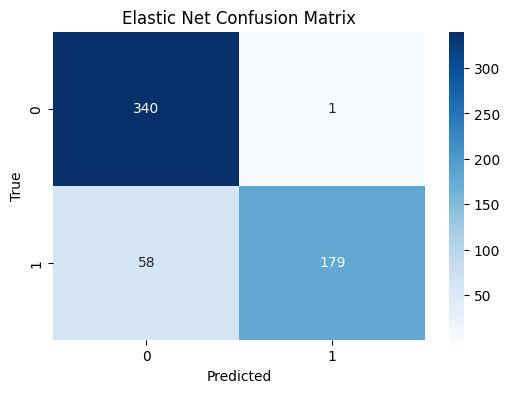

In [21]:
import pandas as pd
from sklearn.linear_model import LogisticRegressionCV
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm  # <-- NEW
import time  # <-- for simulation in tqdm

# Prepare your data
X = filtered_train_df.drop('response', axis=1)
y = filtered_train_df['response']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Setup Elastic Net Logistic Regression
clf_elastic = LogisticRegressionCV(
    Cs=10,
    cv=5,
    penalty='elasticnet',
    solver='saga',
    max_iter=5000,
    random_state=42,
    scoring='accuracy',
    l1_ratios=[0, 0.1, 0.5, 0.7, 0.9, 1],
    class_weight={1:5, 2:1}
)

# Print nice message
print("Training Elastic Net Logistic Regression with Cross-Validation...")
print("(This might take a moment. Showing progress bar...)")

# Use tqdm to show progress
with tqdm(total=1, desc="Training Progress", bar_format="{l_bar}{bar}| {elapsed} elapsed") as pbar:
    clf_elastic.fit(X_train_scaled, y_train)
    pbar.update(1)

# Best parameters
print("\nBest C (inverse of regularization strength) value:", clf_elastic.C_)
print("Best L1 ratio:", clf_elastic.l1_ratio_)

# Coefficients
coeff_df = pd.DataFrame({'Feature': X_train.columns, 'Coefficient': clf_elastic.coef_[0]})
print("\nFeature Coefficients (Elastic Net Regularization):")
print(coeff_df.sort_values(by='Coefficient', key=abs, ascending=False))

# Predictions and evaluation
y_pred = clf_elastic.predict(X_test_scaled)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Heatmap of confusion matrix
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Elastic Net Confusion Matrix")
plt.show()


In [32]:
# 1. Make sure your test_df is prepared
# (It should have the same features and preprocessing as X_train)

# If needed, select only the training features:
X_final_test = test_df[X_train.columns]  # Ensure columns match

# 2. Scale the test data using the SAME scaler
X_final_test_scaled = scaler.transform(X_final_test)

# 3. Predict using the trained model
y_pred_test = clf_elastic.predict(X_final_test_scaled)

# 4. Map the predictions (if needed)
# If your model predicts 0 and 1, and you want to map {0 -> 1, 1 -> 2}
response_pred = pd.Series(y_pred_test)

# 5. Save the predictions
response_pred.to_csv(
    '../prediction/predicted_ELASTICNET.txt',
    sep='\t',
    index=False,
    header=False
)

print("\nPredictions saved successfully to '../prediction/predicted_ELASTICNET.txt'.")



Predictions saved successfully to '../prediction/predicted_ELASTICNET.txt'.
